# Week 5 exercises: Visualization and A/B Testing

*Complete all exercises in this notebook during week 5. The exercises are not submitted — this is purely for your own learning and for preparing for the assignments, project and exam.*

Note! You should always attempt to complete the tasks first without using AI.

---

In [1]:
# Importing needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1: Visualization with Seaborn

### Exercise 1: Scatter plots and distributions

We will use the built-in Seaborn dataset `tips`, which contains data on restaurant bills, tips, and customer attributes.

a) Load the `tips` dataset using `sns.load_dataset()`. Doing some exploratory data analysis is probably a good idea, or reading about the dataset online at least.

b) Create a scatter plot of `total_bill` vs. `tip`, colored by `time` (Lunch vs. Dinner). Add a meaningful title and axis labels.

c) Create a histogram of `total_bill`. Experiment with different values of `bins` (e.g. 10, 20, 50). How does the bin count affect the appearance?

d) Create a KDE plot of `total_bill` grouped by `time` using `sns.kdeplot()` with `fill=True`. Do lunch and dinner bills have different distributions?

In [4]:
# a)
tips = sns.load_dataset("tips")
display(tips.head())

tips.describe()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


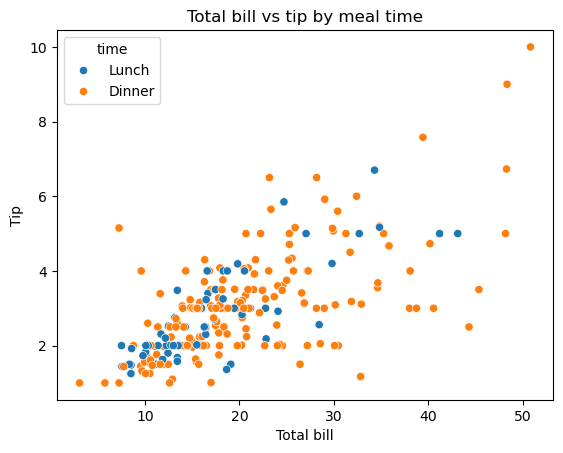

In [10]:
# b)
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.title("Total bill vs tip by meal time")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.show()

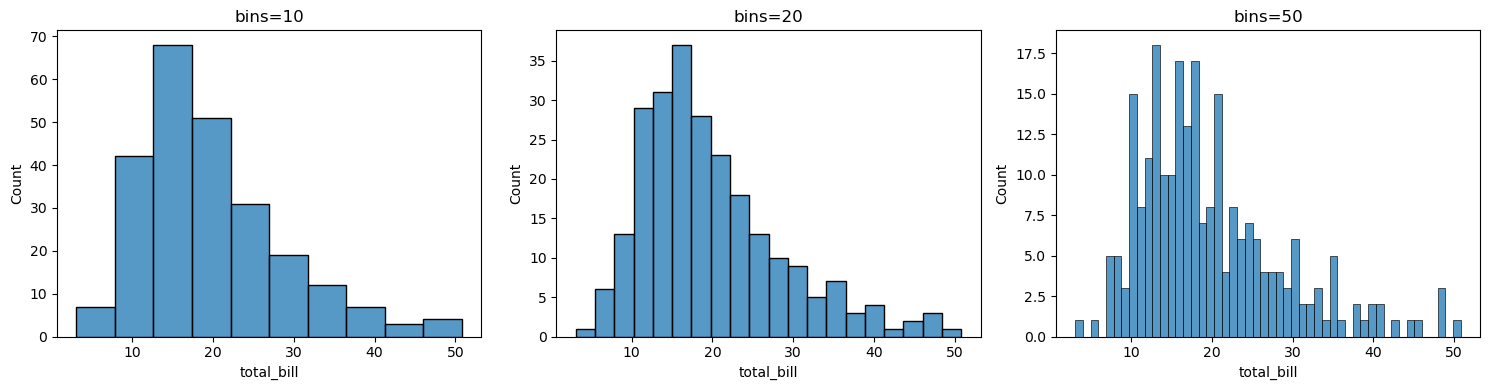

In [14]:
# c)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, b in zip(axes, [10, 20, 50]):
    sns.histplot(tips["total_bill"], bins=b, ax=ax)
    ax.set_title(f"bins={b}")

plt.tight_layout()

#The amount of bins affects how detailed the histogram is, more means more detailed, less means smoother and easier to read

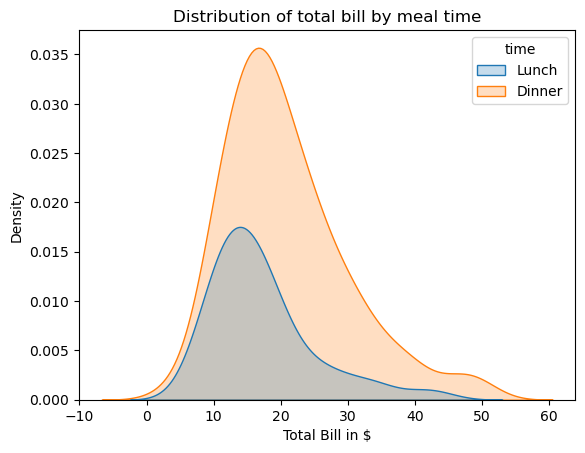

In [19]:
# d) 
sns.kdeplot(data = tips, x = "total_bill", hue = "time", fill = True)
plt.title("Distribution of total bill by meal time")
plt.xlabel("Total Bill in $")
plt.ylabel("Density")
plt.show()

#Dinner bills tend to be higher but also vary more than lunch bills.

### Exercise 2: Categorical plots and heatmaps

a) Create a box plot of `tip` grouped by `day` from the `tips` dataset. Which day has the widest spread in tip amounts? Are there outliers?

b) Create a bar plot showing the mean `total_bill` by `day`, with `hue="sex"`. Does the average bill differ between male and female customers across days?

c) Using `pd.pivot_table()`, create a pivot table showing the mean `tip` for each combination of `day` (rows) and `time` (columns). Display it as a heatmap with `sns.heatmap()` using `annot=True` and a color map of your choice. Are there any day/time combinations that stand out?

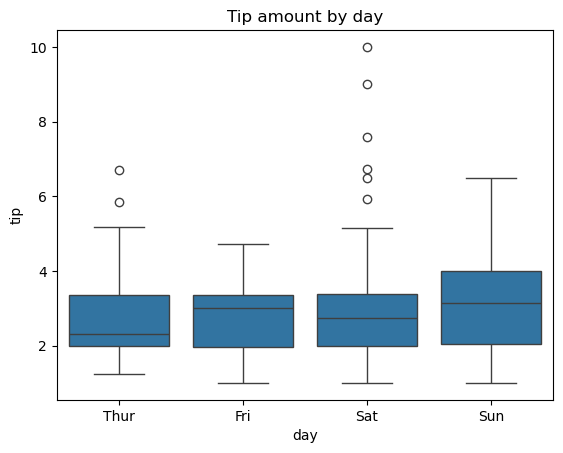

In [23]:
# a
sns.boxplot(data = tips, x = "day", y = "tip")
plt.title("Tip amount by day")
plt.show()

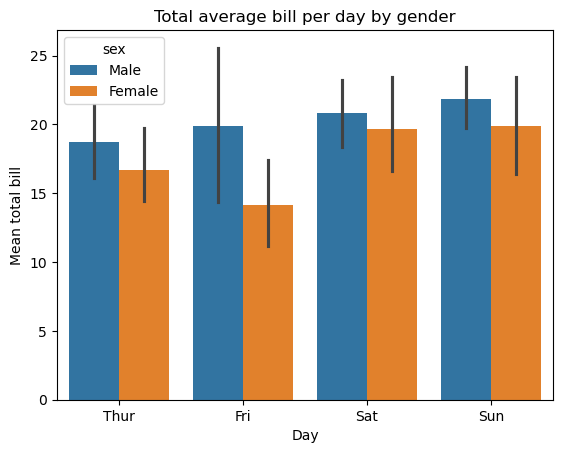

In [28]:
# b
sns.barplot(data = tips, x = "day", y = "total_bill", hue = "sex")
plt.ylabel("Mean total bill")
plt.xlabel("Day")
plt.title("Total average bill per day by gender")
plt.show()

# Gender differences -> male customers tend to have higher bills on average for all days

<Axes: xlabel='time', ylabel='day'>

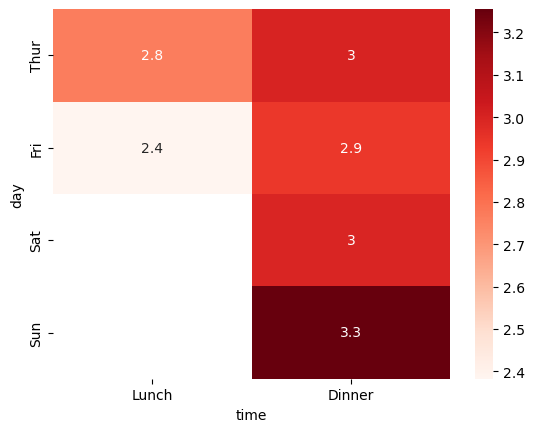

In [35]:
# c
pivot = pd.pivot_table(data = tips, values = "tip", index = "day", columns = "time", aggfunc = "mean", observed = False)
sns.heatmap(data = pivot, cmap = "Reds", annot = True)
plt.title("")
plt.show()

### Exercise 3: Customization and saving

a) Create a scatter plot of `total_bill` vs. `tip` from the `tips` dataset, colored by `smoker`. Set the figure size to 8 by 5 inches using `plt.figure(figsize=(8, 5))`. Add a descriptive title and axis labels.

b) Seaborn has five built-in themes: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks`. Test at least 3 of them by applying a new theme and running the code from one of the previous plotting tasks, such as 2a).

c) Save one of your plots to a file called `tips_scatter.png` into a folder `images` using `plt.savefig()` with `dpi=150` and `bbox_inches="tight"`. Verify that the file was created manually.

In [ ]:
# YOUR CODE HERE


## Part 2: A/B testing

### Exercise 4: Loading and exploring the campaign data

The files `data/control_group.csv` and `data/test_group.csv` contain daily performance metrics from an A/B test comparing two online advertising campaigns during August 2019. Each file has 30 rows (one per day) with the following columns:

- `Campaign Name`: group identifier (Control Campaign or Test Campaign)
- `Date`: the date of the observation
- `Spend [USD]`: advertising spend in dollars
- `# of Impressions`: number of times the ad was shown
- `Reach`: number of unique users who saw the ad
- `# of Website Clicks`: number of clicks to the website
- `# of Searches`: number of product searches on the website
- `# of View Content`: number of product page views
- `# of Add to Cart`: number of add-to-cart events
- `# of Purchase`: number of completed purchases

The original dataset can be found [here](https://www.kaggle.com/datasets/amirmotefaker/ab-testing-dataset).

a) Load both CSV files. Note that the separator is `;`, not `,`. Print the shape and first 5 rows of each.

b) Combine the two DataFrames into a single DataFrame using `pd.concat()`. Verify that the result has 60 rows.

c) Check for missing values with `isna().sum()`. Which group has missing values? How many rows are affected?

d) Drop the rows with missing values and verify the new shape.

In [ ]:
# YOUR CODE HERE


### Exercise 5: Exploratory data analysis

a) Compute the mean of each numeric column grouped by `Campaign Name`. Which campaign spent more on average? Which generated more purchases?

b) Run the code cells below and study the visualizations. Write your observations as comments or in a markdown cell after the plots.

In [ ]:
# YOUR CODE HERE (part a)


In [ ]:
# Part b: bar plot comparing mean purchases
purchase_means = df.groupby("Campaign Name")["# of Purchase"].mean()

sns.barplot(x=purchase_means.index, y=purchase_means.values)
plt.ylabel("Mean daily purchases")
plt.title("Average daily purchases by campaign");

In [ ]:
# Part c: side-by-side box plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="Campaign Name", y="# of Website Clicks", ax=axes[0])
axes[0].set_title("Website Clicks by campaign")

sns.boxplot(data=df, x="Campaign Name", y="# of Add to Cart", ax=axes[1])
axes[1].set_title("Add to Cart by campaign")

plt.tight_layout();

In [ ]:
# Part d: conversion rate comparison
df["Conversion Rate"] = df["# of Purchase"] / df["# of Website Clicks"]

print(df.groupby("Campaign Name")["Conversion Rate"].mean())
print()

sns.kdeplot(data=df, x="Conversion Rate", hue="Campaign Name", fill=True)
plt.title("Distribution of daily conversion rates");

In [ ]:
# YOUR INTERPRETATION HERE (convert this cell to markdown and write them)


### Exercise 6: Choosing and running statistical tests

In this dataset, each row represents daily aggregate metrics for a campaign. We are comparing two independent groups (Control vs. Test) on continuous daily measurements. The appropriate test for comparing the means of two independent groups on a continuous variable is the **independent two-sample t-test**.

Choose **either Option A (SciPy)** or **Option B (tea-tasting)** below.

---

#### Option A: SciPy

a) Import `scipy.stats`. Split the combined DataFrame into two separate DataFrames: one for Control and one for Test.

b) Run an independent two-sample t-test (`scipy.stats.ttest_ind()`) comparing the daily `# of Purchase` between the two campaigns. Print the t-statistic and p-value. Using a significance level of 0.05, is the difference statistically significant?

c) Run the same t-test for `# of Add to Cart` and `# of Website Clicks`. Which of these metrics show a statistically significant difference?

---

#### Option B: tea-tasting

[tea-tasting](https://tea-tasting.e10v.me/) is a Python package designed specifically for A/B test analysis. It provides a high-level API that handles common tasks such as running the appropriate statistical tests and computing confidence intervals.

a) Install tea-tasting with `!pip install tea-tasting` and import it. Since tea-tasting expects data where each row is one unit with a `variant` column, we can use our combined DataFrame with `Campaign Name` as the variant.

b) Define an experiment with `tt.Experiment()` that analyses the following metrics as `tt.Mean()`: `# of Purchase`, `# of Add to Cart`, and `# of Website Clicks`.

c) Run the experiment using `.analyze()` with `Campaign Name` as the variant column. Print the results. Which metrics show a statistically significant difference?

In [ ]:
# Option A: SciPy
from scipy import stats

# YOUR CODE HERE

In [ ]:
# Option B: tea-tasting
# !pip install tea-tasting
# import tea_tasting as tt

# YOUR CODE HERE

### Exercise 7: Interpreting the results

This exercise has no code. Answer the following in a markdown cell or as comments:

Summarize your findings: for which metrics was the difference between the two campaigns statistically significant?

In [ ]:
# YOUR ANSWERS HERE (as comments or convert this cell to markdown)


## Part 3: Text analysis with an LLM

### Exercise 8: Sentiment analysis

In this exercise you will use a large language model to classify the sentiment of customer reviews. You can use **either** a local model via Ollama **or** a cloud API via Gemini. Choose the option that works best for your setup.

**Option A: Ollama (local model)**

```python
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)
MODEL = "llama3.2"

def ask_llm(prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content
```

**Option B: Gemini (cloud API)**

```python
from dotenv import load_dotenv
import os
from google import genai

load_dotenv()
api_key = os.environ.get("GEMINI_API_KEY")
gemini_client = genai.Client(api_key=api_key)
GEMINI_MODEL = "gemini-2.5-flash-lite"

def ask_llm(prompt):
    response = gemini_client.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt
    )
    return response.text
```

a) Choose one of the options above and set up the client. Test that it works by asking: `"What is sentiment analysis? Answer in one sentence."`

b) Create the following DataFrame of fictional reviews for a sushi restaurant:

```python
reviews = pd.DataFrame({
    "review_id": [1, 2, 3, 4, 5, 6],
    "review_text": [
        "Best sushi in town! The salmon nigiri was incredibly fresh and the miso soup was perfect.",
        "Waited 45 minutes for our food and when it arrived the rice was cold. Very disappointing experience.",
        "The fish was fresh but nothing special. Decent enough for a quick lunch, fair price for what you get.",
        "Dragon roll was absolutely amazing and the staff were so friendly. Will definitely come back!",
        "Found a hair in my ramen. The manager did not seem to care at all. Never coming back.",
        "Lovely atmosphere and good green tea. The sashimi platter was fine but the tempura was a bit greasy."
    ]
})
```

c) Write a function `analyse_sentiment(text)` that sends a prompt to the LLM asking it to classify the sentiment as Positive, Negative, or Neutral. The function should return the sentiment label as a string. **Hint:** instruct the model to respond with exactly one word.

d) Apply the function to all reviews using `.apply()` and store the results in a new column called `sentiment`. Print the resulting DataFrame. Do the labels match your own judgment?

In [ ]:
# YOUR CODE HERE
